# Cell 1: Setup

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Check if GPU available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Cell 2: Load raw beats (not feature matrix)

In [2]:
import wfdb
import wfdb.processing
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=2):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def process_record(record_id, data_dir='data/mitdb'):
    record_path = os.path.join(data_dir, str(record_id))
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, 'atr')
    signal = record.p_signal[:, 0]
    fs = record.fs
    filtered = bandpass_filter(signal, fs)
    peaks = wfdb.processing.gqrs_detect(filtered, fs=fs)

    window_before = int(0.2 * fs)
    window_after = int(0.4 * fs)
    beats, valid_peaks = [], []
    for peak in peaks:
        start = peak - window_before
        end = peak + window_after
        if start >= 0 and end < len(filtered):
            beats.append(filtered[start:end])
            valid_peaks.append(peak)

    non_beat = {'+', '~', '|', 'x', '[', ']', '(', ')'}
    ann_samples = annotation.sample.astype(np.int64)
    ann_symbols = annotation.symbol
    beat_labels = []
    for peak in valid_peaks:
        diffs = np.abs(ann_samples - peak)
        idx = np.argmin(diffs)
        if diffs[idx] <= 20 and ann_symbols[idx] not in non_beat:
            beat_labels.append(ann_symbols[idx])
        else:
            beat_labels.append('U')

    return np.array(beats), np.array(beat_labels)

# Load all four records
records_to_use = ['100', '106', '109', '212']
all_beats, all_labels = [], []
for rec_id in records_to_use:
    beats, labels = process_record(rec_id)
    all_beats.extend(beats)
    all_labels.extend(labels)

all_beats = np.array(all_beats)
all_labels = np.array(all_labels)

# Remove unlabelled and F class
mask = (all_labels != 'U') & (all_labels != 'F')
all_beats = all_beats[mask]
all_labels = all_labels[mask]

print(f"Beat array shape: {all_beats.shape}")
print(f"Class distribution: {Counter(all_labels)}")

Beat array shape: (9561, 216)
Class distribution: Counter({'N': 4665, 'L': 2491, 'R': 1825, 'V': 547, 'A': 33})


# Cell 3: Encode labels and normalise beats

In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(all_labels)
print(f"Classes: {le.classes_}")
print(f"Encoded: {np.unique(y_encoded)}")

# Normalise each beat to zero mean, unit std
beat_mean = all_beats.mean(axis=1, keepdims=True)
beat_std = all_beats.std(axis=1, keepdims=True) + 1e-8
beats_norm = (all_beats - beat_mean) / beat_std
print(f"Normalised beats shape: {beats_norm.shape}")

Classes: ['A' 'L' 'N' 'R' 'V']
Encoded: [0 1 2 3 4]
Normalised beats shape: (9561, 216)


# Cell 4: Train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    beats_norm, y_encoded,
    test_size=0.2, random_state=42,
    stratify=y_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class distribution: {Counter(y_train)}")

Train: (7648, 216), Test: (1913, 216)
Train class distribution: Counter({2: 3732, 1: 1993, 3: 1460, 4: 437, 0: 26})


# Cell 5: PyTorch Dataset

In [5]:
class ECGDataset(Dataset):
    def __init__(self, beats, labels):
        # Shape: (N, 1, L) — 1 channel, L samples
        self.X = torch.tensor(beats, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 120
Test batches: 30


# Cell 6: Define 1D CNN

In [6]:
class ECG_CNN(nn.Module):
    def __init__(self, input_length, num_classes):
        super(ECG_CNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        # Calculate flattened size
        conv_out = input_length // 8
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * conv_out, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc(x)
        return x

input_length = X_train.shape[1]  # 216 samples per beat
num_classes = len(le.classes_)

model = ECG_CNN(input_length, num_classes).to(device)
print(model)
print(f"\nInput length: {input_length}")
print(f"Number of classes: {num_classes}")

ECG_CNN(
  (conv_block): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3456, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
  

# Cell 7: Class weights for imbalanced data

In [7]:
class_counts = Counter(y_train)
total = sum(class_counts.values())
weights = torch.tensor(
    [total / (len(class_counts) * class_counts[i]) for i in range(len(class_counts))],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
print(f"Class weights: {weights.cpu().numpy()}")

Class weights: [58.83077     0.7674862   0.40986067  1.0476712   3.500229  ]


# Cell 8: Training loop

In [8]:
num_epochs = 15
train_losses, train_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += y_batch.size(0)

    scheduler.step()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

Epoch 01/15 | Loss: 0.4011 | Acc: 0.8915
Epoch 02/15 | Loss: 0.1830 | Acc: 0.9358
Epoch 03/15 | Loss: 0.1464 | Acc: 0.9323
Epoch 04/15 | Loss: 0.1290 | Acc: 0.9571
Epoch 05/15 | Loss: 0.1200 | Acc: 0.9527
Epoch 06/15 | Loss: 0.0834 | Acc: 0.9707
Epoch 07/15 | Loss: 0.0465 | Acc: 0.9839
Epoch 08/15 | Loss: 0.0408 | Acc: 0.9889
Epoch 09/15 | Loss: 0.0367 | Acc: 0.9914
Epoch 10/15 | Loss: 0.0217 | Acc: 0.9940
Epoch 11/15 | Loss: 0.0260 | Acc: 0.9910
Epoch 12/15 | Loss: 0.0155 | Acc: 0.9958
Epoch 13/15 | Loss: 0.0124 | Acc: 0.9965
Epoch 14/15 | Loss: 0.0061 | Acc: 0.9986
Epoch 15/15 | Loss: 0.0108 | Acc: 0.9976


# Cell 9: Plot training curves

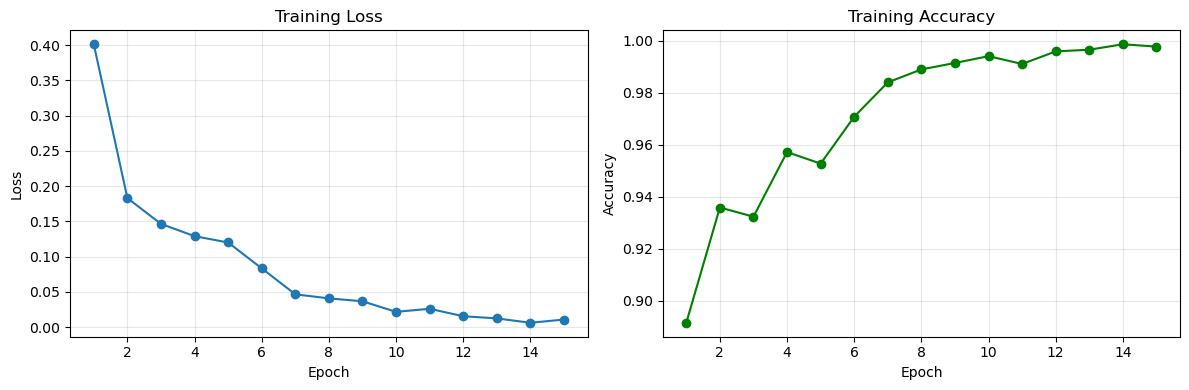

Saved: figures/cnn_training_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, num_epochs+1), train_losses, marker='o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, num_epochs+1), train_accs, marker='o', color='green')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/cnn_training_curves.png', dpi=150)
plt.show()
print("Saved: figures/cnn_training_curves.png")

# Cell 10: Evaluate CNN on test set

In [10]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("CNN Per-class F1 scores:")
print(classification_report(all_targets, all_preds,
                             target_names=le.classes_, digits=3))

cnn_weighted_f1 = f1_score(all_targets, all_preds, average='weighted')
print(f"CNN Weighted F1: {cnn_weighted_f1:.3f}")

CNN Per-class F1 scores:
              precision    recall  f1-score   support

           A      0.875     1.000     0.933         7
           L      1.000     1.000     1.000       498
           N      0.999     0.999     0.999       933
           R      1.000     1.000     1.000       365
           V      1.000     0.991     0.995       110

    accuracy                          0.999      1913
   macro avg      0.975     0.998     0.986      1913
weighted avg      0.999     0.999     0.999      1913

CNN Weighted F1: 0.999


# Cell 11: Comparison table

In [11]:
rf_f1_per_class = {'A': 0.923, 'L': 0.999, 'N': 0.998, 'R': 0.993, 'V': 0.986}
rf_weighted_f1 = 0.996

cnn_f1_per_class = dict(zip(
    le.classes_,
    f1_score(all_targets, all_preds, average=None, labels=range(len(le.classes_)))
))

print(f"{'Class':<8} {'RF F1':>10} {'CNN F1':>10}")
print("-" * 30)
for cls in le.classes_:
    print(f"{cls:<8} {rf_f1_per_class.get(cls, 0):>10.3f} {cnn_f1_per_class.get(cls, 0):>10.3f}")
print("-" * 30)
print(f"{'Weighted':<8} {rf_weighted_f1:>10.3f} {cnn_weighted_f1:>10.3f}")

Class         RF F1     CNN F1
------------------------------
A             0.923      0.933
L             0.999      1.000
N             0.998      0.999
R             0.993      1.000
V             0.986      0.995
------------------------------
Weighted      0.996      0.999


# Cell 12: Save comparison figure

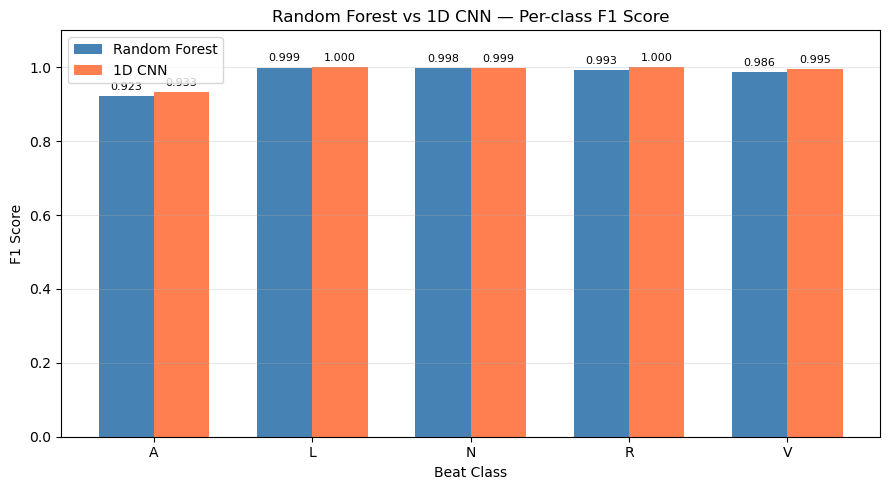

Saved: figures/rf_vs_cnn_comparison.png


In [12]:
classes = le.classes_
rf_vals = [rf_f1_per_class.get(c, 0) for c in classes]
cnn_vals = [cnn_f1_per_class.get(c, 0) for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, cnn_vals, width, label='1D CNN', color='coral')
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.set_xlabel('Beat Class')
ax.set_ylabel('F1 Score')
ax.set_title('Random Forest vs 1D CNN — Per-class F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/rf_vs_cnn_comparison.png', dpi=150)
plt.show()
print("Saved: figures/rf_vs_cnn_comparison.png")